In [ ]:
# read final_df from csv file
import pandas as pd
df_final = pd.read_csv(r'd:/Github/Data/final_material_data_20250114.csv')
# exclude historical buildings before 1930
df_final_wt_hb = df_final[df_final['year of construction of the building yyyy'] >= 1930]
# # exclude buildings newer than 2020
# df_final_wt_hb = df_final_wt_hb[df_final_wt_hb['year of construction of the building yyyy'] <= 2020]
# remove bathtubs for all buildings except residential buildings
df_final_wt_hb = df_final_wt_hb[~((df_final_wt_hb['component'] == 'bathtub') & (df_final_wt_hb['building class'] != 'residential'))]
# add stainless steel and steel to be the same material
df_final_wt_hb['material'] = df_final_wt_hb['material'].replace({'stainless steel': 'steel'})
# Define component lifespan
component_lifespan = {
    'electrical cable': 50,
    'boiler': 35,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 35,
    'heat pump': 30,
    'toilet': 50,
    'shower': 30,
    'sink': 50,
    'bathtub': 50
}

# Add end-of-life year for each component
df_final_wt_hb['end_of_life_year'] = df_final_wt_hb['year of construction of the building yyyy'] + df_final_wt_hb['component'].map(component_lifespan)

# Group by decade of end-of-life year and material type, summing material weights
df_final_wt_hb['end_of_life_decade'] = (df_final_wt_hb['end_of_life_year'] // 10) * 10
material_availability = df_final_wt_hb.groupby(['end_of_life_decade', 'material'])['material_weight'].sum().unstack(fill_value=0)

In [ ]:
# Latin Hypercube Sampling to identify the best path for each component
from SALib.sample import latin
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ 1. 定义组件数据
components = pd.DataFrame([
    ['Electrical Cable', 5, 5, 5, 1, 1, 1, 5],
    ['Boiler', 5, 5, 5, 3, 3, 4, 5],
    ['Water Pipe', 5, 1, 5, 1, 1, 1, 1],
    ['Air Duct', 1, 1, 5, 1, 1, 5, 5],
    ['Radiator', 1, 1, 5, 3, 3, 5, 5],
    ['Heat Pump', 5, 5, 5, 3, 3, 5, 5],
    ['Toilet', 5, 5, 1, 4, 4, 3, 1],
    ['Sink', 5, 5, 1, 4, 4, 3, 1],
    ['Shower', 5, 5, 1, 4, 4, 3, 1],
    ['Bathtub', 5, 5, 1, 4, 4, 3, 1]
], columns=[
    'Component', 'Compatibility', 'Regulation', 'Disposal',
    'Lifespan', 'Disassembly', 'CostEffective', 'MaterialContent'
])

# ✅ 2. 定义权重空间（15个参数）
param_bounds = [
    ('a1', 1, 3), ('a2', 1, 3), ('a3', 1, 3), ('a4', 1, 3), ('a5', 1, 3),
    ('b1', 1, 3), ('b2', 1, 3), ('b3', 1, 3), ('b4', 1, 3),
    ('g1', 1, 3), ('g2', 1, 3),
    ('d1', 0.5, 2), ('d2', 0.5, 2), ('d3', 0.5, 2)
]

problem = {
    'num_vars': len(param_bounds),
    'names': [p[0] for p in param_bounds],
    'bounds': [[p[1], p[2]] for p in param_bounds]
}

# ✅ 3. Latin Hypercube Sampling
n_samples = 300
lhs_samples = latin.sample(problem, N=n_samples)
lhs_param_samples = pd.DataFrame(lhs_samples, columns=problem['names'])

# ✅ 4. 模型运行：计算最优路径
lhs_results = []

for i, weights in lhs_param_samples.iterrows():
    for _, row in components.iterrows():
        RS = weights['a1'] * row['Compatibility'] + weights['a2'] * row['Regulation'] + \
             weights['a3'] * row['Disposal'] + weights['a4'] * row['Lifespan'] + weights['a5'] * row['Disassembly']
        RF = weights['b1'] * row['Lifespan'] + weights['b2'] * row['Disassembly'] + \
             weights['b3'] * row['Compatibility'] + weights['b4'] * row['Regulation']
        RC = weights['g1'] * row['MaterialContent'] + weights['g2'] * row['CostEffective']
        DS = weights['d1'] * row['Disposal'] + weights['d2'] * row['Compatibility'] + weights['d3'] * row['Lifespan']

        scores = {'Reuse': RS, 'Refurbish': RF, 'Recycle': RC, 'Disposal': DS}
        best_path = max(scores, key=scores.get)

        lhs_results.append({
            'Component': row['Component'],
            'Scenario_ID': i,
            'BestPath': best_path
        })

# ✅ 5. 汇总结果
lhs_df_results = pd.DataFrame(lhs_results)
lhs_summary = lhs_df_results.groupby(['Component', 'BestPath']).size().unstack(fill_value=0)
lhs_summary_percent = lhs_summary.div(lhs_summary.sum(axis=1), axis=0) * 100

print(lhs_summary_percent.round(1))

# # ✅ 6. 模拟敏感性分析数据 + 绘制4路径热力图
# paths = ['Reuse', 'Refurbish', 'Recycle', 'Disposal']
# parameters = problem['names']

# np.random.seed(42)
# sensitivity_all = {}
# for path in paths:
#     s1 = np.random.rand(len(parameters)) * 0.05
#     st = np.random.rand(len(parameters)) * 0.1
#     if path == 'Reuse':
#         st[0:5] += 0.3  # a1–a5
#     elif path == 'Refurbish':
#         st[5:9] += 0.3  # b1–b4
#     elif path == 'Recycle':
#         st[9:11] += 0.3  # g1–g2
#     elif path == 'Disposal':
#         st[11:] += 0.3  # d1–d3
#     sensitivity_all[path] = pd.DataFrame({'S1': s1, 'ST': st}, index=parameters)

# # 画图
# fig, axes = plt.subplots(1, 4, figsize=(20, 8), sharey=True)
# for i, path in enumerate(paths):
#     ax = axes[i]
#     sns.heatmap(sensitivity_all[path], annot=True, cmap="YlOrRd", cbar=i==3,
#                 fmt=".2f", ax=ax, vmin=0, vmax=0.5)
#     ax.set_title(f"{path} Path")
#     ax.set_ylabel('' if i > 0 else 'Parameter')

# plt.suptitle("Sensitivity Indices Heatmaps for Each Pathway", fontsize=16, y=1.02)
# plt.tight_layout()
# plt.show()


BestPath          Disposal  Recycle  Refurbish  Reuse
Component                                            
Air Duct               0.0     63.7        0.0   36.3
Bathtub                0.0      0.0       40.0   60.0
Boiler                 0.0      0.0        8.0   92.0
Electrical Cable       0.0      0.0        5.3   94.7
Heat Pump              0.0      0.0        8.0   92.0
Radiator               0.0     15.3        0.7   84.0
Shower                 0.0      0.0       40.0   60.0
Sink                   0.0      0.0       40.0   60.0
Toilet                 0.0      0.0       40.0   60.0
Water Pipe             0.7      0.0        3.3   96.0


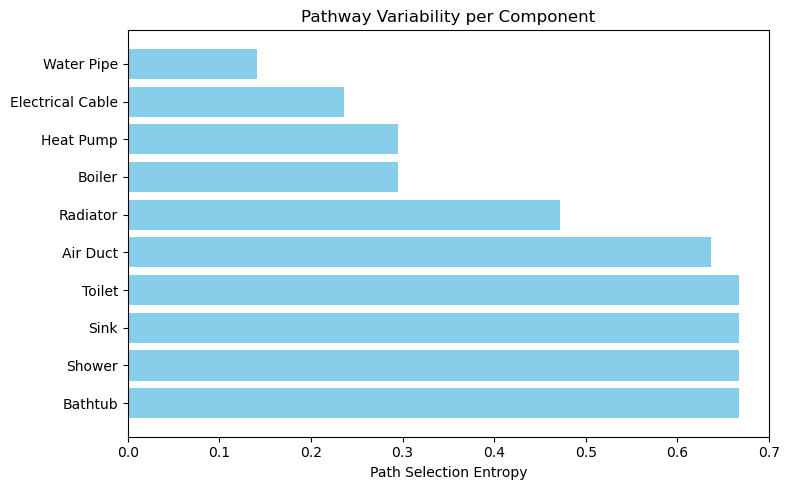

In [ ]:
# # ✅ 7. 绘制路径选择熵图
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# 汇总各组件各路径频率
lhs_summary = lhs_df_results.groupby(['Component', 'BestPath']).size().unstack(fill_value=0)
lhs_summary_percent = lhs_summary.div(lhs_summary.sum(axis=1), axis=0) * 100

# 计算每个组件路径选择的熵（衡量路径分布的离散程度）
lhs_entropy = lhs_summary_percent.apply(lambda row: entropy(row / 100), axis=1)
entropy_df = pd.DataFrame({'Component': lhs_entropy.index, 'Path_Entropy': lhs_entropy.values})
entropy_df.sort_values('Path_Entropy', ascending=False, inplace=True)

# 绘制条形图
plt.figure(figsize=(8, 5))
plt.barh(entropy_df['Component'], entropy_df['Path_Entropy'], color='skyblue')
plt.xlabel('Path Selection Entropy')
plt.title('Pathway Variability per Component')
plt.tight_layout()
plt.show()


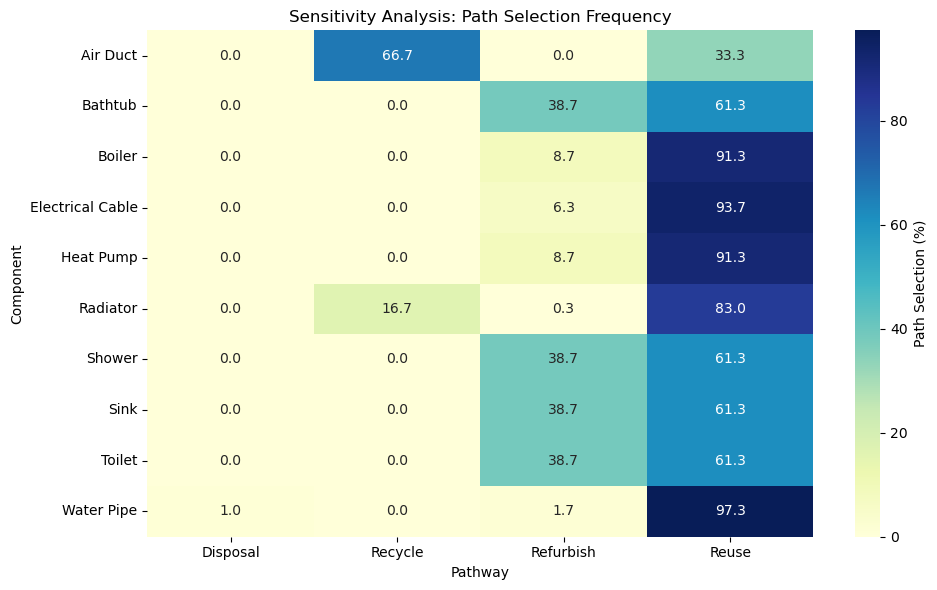

In [ ]:
# ✅ 直接使用 lhs_summary_percent 画热图
plt.figure(figsize=(10, 6))
sns.heatmap(lhs_summary_percent, annot=True, cmap="YlGnBu", fmt=".1f", cbar_kws={'label': 'Path Selection (%)'})
plt.title("Sensitivity Analysis: Path Selection Frequency")
plt.ylabel("Component")
plt.xlabel("Pathway")
plt.tight_layout()
plt.show()

In [ ]:
# inverse modeling to estimate the weights for the model based on current practice
# # Full code to reconstruct the entire modeling process as a standalone script

# Step 1: Imports
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge

# Step 2: Data definition
# Component features
feature_data = {
    "Component": [
        "Electrical Cable", "Boiler", "Water Pipe", "Air Duct", "Radiator",
        "Heat Pump", "Toilet", "Sink", "Shower", "Bathtub"
    ],
    "Material": [
        "Copper", "Steel", "PEX", "Aluminum", "Steel",
        "Steel", "Ceramic", "Ceramic", "Ceramic", "Ceramic"
    ],
    "Technological Compatibility": [5, 5, 5, 1, 1, 5, 5, 5, 5, 5],
    "Regulatory Compliance": [5, 5, 1, 1, 1, 5, 5, 5, 5, 5],
    "Disposal and Energy Recovery": [5, 5, 5, 5, 5, 5, 1, 1, 1, 1],
    "Lifespan Qualification": [1, 3, 1, 1, 3, 3, 4, 4, 4, 4],
    "New/Good Condition/Disassembly Easiness": [1, 3, 1, 1, 3, 3, 4, 4, 4, 4],
    "Cost-Effective": [1, 4, 1, 5, 5, 5, 3, 3, 3, 3],
    "Metal Content": [5, 5, 1, 5, 5, 5, 1, 1, 1, 1]
}
df_features = pd.DataFrame(feature_data)

# Current practice percentage
pathway_data = {
    "Reuse": [0.1, 0.05, 0.2, 0.15, 0.05, 0.05, 0.1, 0.1, 0.05, 0.05],
    "Recycle": [0.4, 0.5, 0.3, 0.45, 0.25, 0.55, 0.2, 0.2, 0.15, 0.15],
    "Refurbish": [0.1, 0.1, 0.1, 0.15, 0.05, 0.15, 0.05, 0.05, 0.05, 0.05],
    "Disposal": [0.4, 0.35, 0.4, 0.25, 0.65, 0.25, 0.65, 0.65, 0.75, 0.75]
}
df_pathways = pd.DataFrame(pathway_data)

# Step 3: Feature normalization
features = [
    "Technological Compatibility", "Regulatory Compliance", "Disposal and Energy Recovery",
    "Lifespan Qualification", "New/Good Condition/Disassembly Easiness",
    "Cost-Effective", "Metal Content"
]
scaler = MinMaxScaler()
X_features = scaler.fit_transform(df_features[features])

# Step 4: Fit Ridge regression model to estimate weights
reg_model = Ridge(alpha=0.1)
reg_model.fit(X_features, df_pathways)

# Step 5: Extract and display the weights
weights_df = pd.DataFrame(reg_model.coef_, columns=features, index=["Reuse", "Recycle", "Refurbish", "Disposal"])
weights_df


,Technological Compatibility,Regulatory Compliance,Disposal and Energy Recovery,Lifespan Qualification,New/Good Condition/Disassembly Easiness,Cost-Effective,Metal Content
Reuse,0.016209,-0.029739,-0.011906,-0.055562,-0.055562,0.016510,-0.057854
Recycle,0.149885,0.081971,0.122482,-0.092662,-0.092662,0.221378,0.054568
Refurbish,0.041736,0.020796,0.010855,-0.051346,-0.051346,0.090233,-0.010085
Disposal,-0.207831,-0.073029,-0.121431,0.199571,0.199571,-0.328120,0.013371


In [27]:
# weight estimation based on current practice but with predefined theoretical formulas

# Step 1: Imports
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge

# Step 2: Data definition
# Component features
feature_data = {
    "Component": [
        "Electrical Cable", "Boiler", "Water Pipe", "Air Duct", "Radiator",
        "Heat Pump", "Toilet", "Sink", "Shower", "Bathtub"
    ],
    "Material": [
        "Copper", "Steel", "PEX", "Aluminum", "Steel",
        "Steel", "Ceramic", "Ceramic", "Ceramic", "Ceramic"
    ],
    "Technological Compatibility": [5, 5, 5, 1, 1, 5, 5, 5, 5, 5],
    "Regulatory Compliance": [5, 5, 1, 1, 1, 5, 5, 5, 5, 5],
    "Disposal and Energy Recovery": [5, 5, 5, 5, 5, 5, 1, 1, 1, 1],
    "Lifespan Qualification": [1, 3, 1, 1, 3, 3, 4, 4, 4, 4],
    "New/Good Condition/Disassembly Easiness": [1, 3, 1, 1, 3, 3, 4, 4, 4, 4],
    "Cost-Effective": [1, 4, 1, 5, 5, 5, 3, 3, 3, 3],
    "Metal Content": [5, 5, 1, 5, 5, 5, 1, 1, 1, 1]
}
df_features = pd.DataFrame(feature_data)

# Current practice percentage
pathway_data = {
    "Reuse": [0.1, 0.05, 0.2, 0.15, 0.05, 0.05, 0.1, 0.1, 0.05, 0.05],
    "Recycle": [0.4, 0.5, 0.3, 0.45, 0.25, 0.55, 0.2, 0.2, 0.15, 0.15],
    "Refurbish": [0.1, 0.1, 0.1, 0.15, 0.05, 0.15, 0.05, 0.05, 0.05, 0.05],
    "Disposal": [0.4, 0.35, 0.4, 0.25, 0.65, 0.25, 0.65, 0.65, 0.75, 0.75]
}
df_pathways = pd.DataFrame(pathway_data)

# Step 3: Feature normalization
features = [
    "Technological Compatibility", "Regulatory Compliance", "Disposal and Energy Recovery",
    "Lifespan Qualification", "New/Good Condition/Disassembly Easiness",
    "Cost-Effective", "Metal Content"
]
scaler = MinMaxScaler()
X_features = scaler.fit_transform(df_features[features])
X_norm = pd.DataFrame(X_features, columns=features)

# Step 4: Define theoretical formulas (feature selection per pathway)
reuse_features = ["Technological Compatibility", "Regulatory Compliance",
                  "New/Good Condition/Disassembly Easiness", "Lifespan Qualification",
                  "Disposal and Energy Recovery"]
refurbish_features = ["Lifespan Qualification", "Disposal and Energy Recovery",
                      "Cost-Effective", "Regulatory Compliance"]
recycle_features = ["Metal Content", "Cost-Effective", "Disposal and Energy Recovery"]
disposal_features = ["New/Good Condition/Disassembly Easiness", "Cost-Effective", "Lifespan Qualification"]

# Step 5: Ridge regression per pathway
def fit_pathway_model(y, X, feature_list):
    model = Ridge(alpha=0.1)
    model.fit(X[feature_list], y)
    return pd.Series(model.coef_, index=feature_list)

y_reuse = df_pathways["Reuse"]
y_refurbish = df_pathways["Refurbish"]
y_recycle = df_pathways["Recycle"]
y_disposal = df_pathways["Disposal"]

reuse_weights = fit_pathway_model(y_reuse, X_norm, reuse_features)
refurbish_weights = fit_pathway_model(y_refurbish, X_norm, refurbish_features)
recycle_weights = fit_pathway_model(y_recycle, X_norm, recycle_features)
disposal_weights = fit_pathway_model(y_disposal, X_norm, disposal_features)

# Combine weights
custom_weight_df = pd.DataFrame({
    "Reuse": reuse_weights,
    "Refurbish": refurbish_weights,
    "Recycle": recycle_weights,
    "Disposal": disposal_weights
}).fillna("")


custom_weight_df


,Reuse,Refurbish,Recycle,Disposal
Cost-Effective,,0.052517,0.017344,-0.190948
Disposal and Energy Recovery,-0.058445,0.016474,0.12913,
Lifespan Qualification,-0.050326,-0.078604,,0.18127
Metal Content,,,0.115986,
New/Good Condition/Disassembly Easiness,-0.050326,,,0.18127
Regulatory Compliance,-0.07191,0.035589,,
Technological Compatibility,0.051529,,,


## *Read dataset to estimate weights*

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge

feature_columns = [
    "Technological Compatibility", "Regulatory Compliance", "Disposal and Energy Recovery",
    "Lifespan Qualification", "New/Good Condition/Disassembly Easiness",
    "Cost-Effective", "Metal Content"
]
target_columns = ["Reuse", "Recycle", "Refurbish", "Disposal"]

# read csv file
all_data = pd.read_csv("dataset1.csv")
combined_df = pd.concat(all_data, ignore_index=True)

# === STEP 4: FEATURE NORMALIZATION ===
scaler = MinMaxScaler()
X = scaler.fit_transform(combined_df[feature_columns])
Y = combined_df[target_columns]

# === STEP 5: TRAIN RIDGE REGRESSION ===
model = Ridge(alpha=0.1)
model.fit(X, Y)

# === STEP 6: EXTRACT WEIGHTS ===
weights_df = pd.DataFrame(
    model.coef_,
    columns=feature_columns,
    index=target_columns
)

# === STEP 7: EXPORT RESULTS ===
weights_df.to_csv("trained_pathway_weights.csv", index=True)
print("✅ Model trained and saved to 'trained_pathway_weights.csv'.")


In [1]:
# Step 1: Imports
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

# Step 2: Load survey feature data (replace with your actual file path if needed)
df_features = pd.read_csv("dataset1.csv")

# Step 3: Add pathway percentages (from your provided data)
from io import StringIO

pathway_data_csv = """
Component,Reuse,Recycle,Refurbish,Disposal
Electrical Cable,0.1,0.4,0.1,0.4
Boiler,0.05,0.5,0.1,0.35
Water Pipe,0.2,0.3,0.1,0.4
Air Duct,0.15,0.45,0.15,0.25
Radiator,0.05,0.25,0.05,0.65
Heat Pump,0.05,0.55,0.15,0.25
Toilet,0.1,0.2,0.05,0.65
Sink,0.1,0.2,0.05,0.65
Shower,0.05,0.15,0.05,0.75
Bathtub,0.05,0.15,0.05,0.75
"""
df_pathways = pd.read_csv(StringIO(pathway_data_csv))

# Step 4: Merge feature data with pathway data
df = pd.merge(df_features, df_pathways, on="Component")

# Step 5: Normalize selected features
features = [
    "Technological Compatibility", "Regulatory Compliance", "Disposal and Energy Recovery",
    "Lifespan Qualification", "New/Good Condition/Disassembly Easiness",
    "Cost-Effective", "Metal Content"
]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[features])
X_df = pd.DataFrame(X_scaled, columns=features)

# Step 6: Fit regression models for each pathway
Y_df = df[["Reuse", "Recycle", "Refurbish", "Disposal"]]
regression_results = {}

for pathway in Y_df.columns:
    model = LinearRegression()
    model.fit(X_df, Y_df[pathway])
    regression_results[pathway] = model.coef_

# Step 7: Output the resulting weights as a DataFrame
weights_df = pd.DataFrame(regression_results, index=features)
print("=== Pathway Score Weights ===")
print(weights_df)

# (Optional) Save to CSV
weights_df.to_csv("pathway_score_weights.csv")


=== Pathway Score Weights ===
                                            Reuse   Recycle  Refurbish  \
Technological Compatibility              0.030872  0.134348   0.034986   
Regulatory Compliance                   -0.063793  0.063481   0.006158   
Disposal and Energy Recovery            -0.012156  0.162348   0.027691   
Lifespan Qualification                  -0.041327 -0.068248  -0.039850   
New/Good Condition/Disassembly Easiness -0.053812 -0.050799  -0.026526   
Cost-Effective                          -0.018004  0.130126   0.041316   
Metal Content                           -0.035295  0.139590   0.021978   

                                         Disposal  
Technological Compatibility             -0.200206  
Regulatory Compliance                   -0.005847  
Disposal and Energy Recovery            -0.177884  
Lifespan Qualification                   0.149425  
New/Good Condition/Disassembly Easiness  0.131137  
Cost-Effective                          -0.153438  
Metal Content

In [3]:
from IPython.display import display
display(weights_df)
from sklearn.metrics import r2_score

# Step 8: Calculate R² for each regression model
r2_scores = {}

for pathway in Y_df.columns:
    model = LinearRegression()
    model.fit(X_df, Y_df[pathway])
    y_pred = model.predict(X_df)
    r2_scores[pathway] = r2_score(Y_df[pathway], y_pred)

# Convert R² results to a DataFrame for display
r2_df = pd.DataFrame.from_dict(r2_scores, orient='index', columns=["R² Score"])
r2_df


,Reuse,Recycle,Refurbish,Disposal
Technological Compatibility,0.030872,0.134348,0.034986,-0.200206
Regulatory Compliance,-0.063793,0.063481,0.006158,-0.005847
Disposal and Energy Recovery,-0.012156,0.162348,0.027691,-0.177884
Lifespan Qualification,-0.041327,-0.068248,-0.039850,0.149425
New/Good Condition/Disassembly Easiness,-0.053812,-0.050799,-0.026526,0.131137
Cost-Effective,-0.018004,0.130126,0.041316,-0.153438
Metal Content,-0.035295,0.139590,0.021978,-0.126273


,R² Score
Reuse,0.728780
Recycle,0.841218
Refurbish,0.664508
Disposal,0.757735


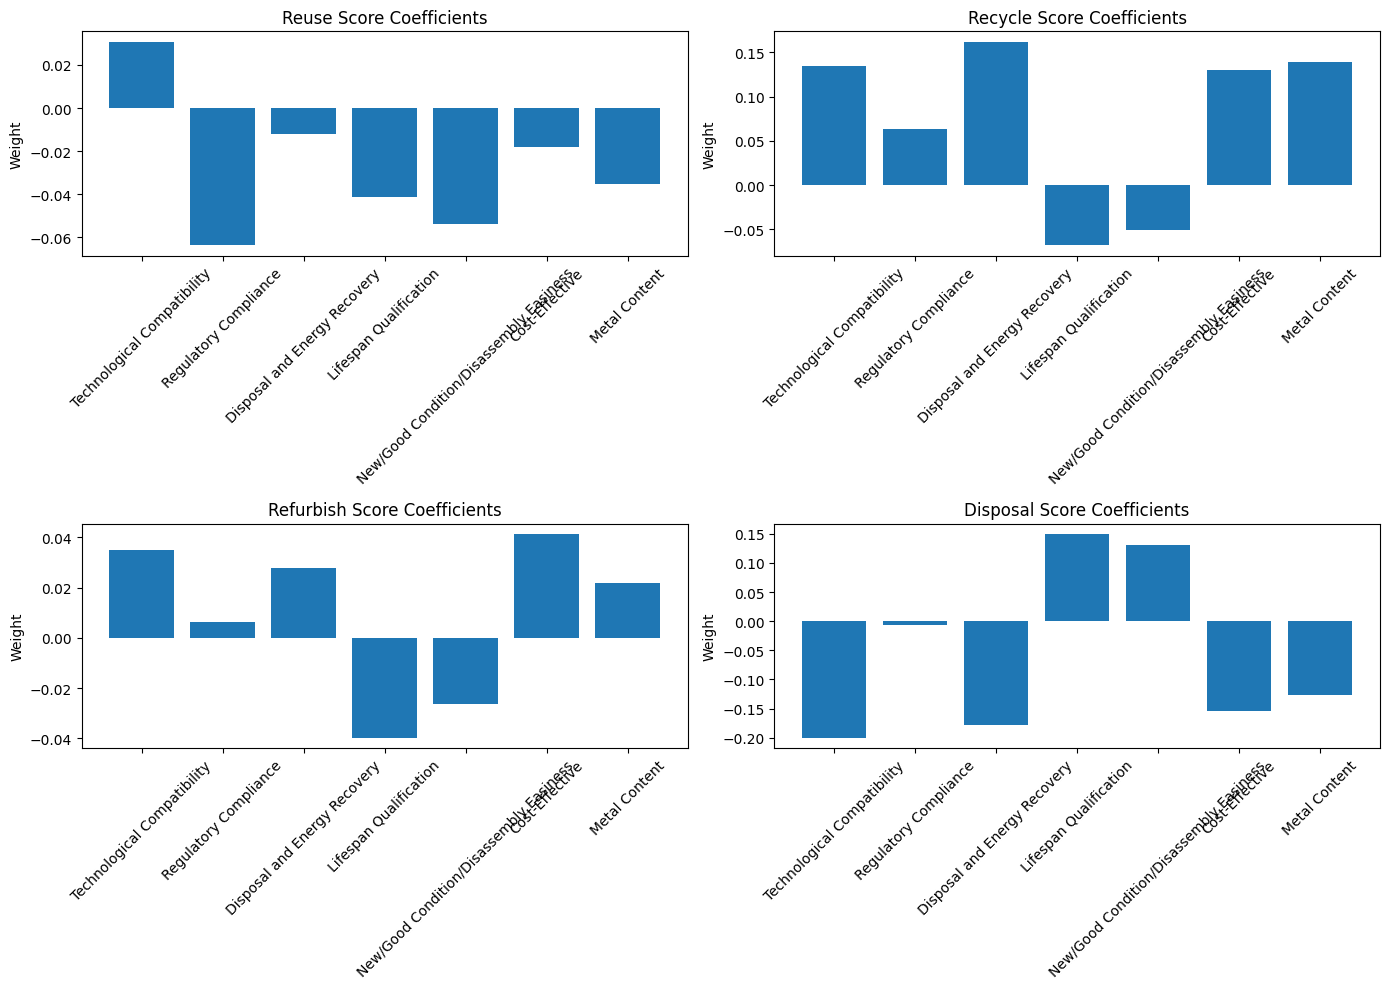

In [4]:
import matplotlib.pyplot as plt

# Plot the weights for each pathway
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, pathway in enumerate(weights_df.columns):
    axes[i].bar(weights_df.index, weights_df[pathway])
    axes[i].set_title(f"{pathway} Score Coefficients")
    axes[i].set_ylabel("Weight")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# **Add Reuse/Recycle/Refurbish/Disposal post flows**

In [5]:
import pandas as pd

# Sample data
data = {
    "year_of_construction": [1530.0, 1530.0, 1530.0, 1530.0, 1530.0, 2021.0, 2021.0, 2021.0, 2021.0, 2021.0],
    "building_class": ["housing"]*10,
    "building_system": ["electrical system", "electrical system", "heating system", "heating system", "heating system", "plumbing system", "plumbing system", "plumbing system", "plumbing system", "plumbing system"],
    "sub_system": ["electrical wiring and cables", "electrical wiring and cables", "heating", "heating", "heating", "drainage and waste pipes", "water supply pipes and fixtures", "water supply pipes and fixtures", "water supply pipes and fixtures", "water supply pipes and fixtures"],
    "component": ["electrical cable", "electrical cable", "boiler", "boiler", "boiler", "water pipe", "water pipe", "water pipe", "water pipe", "water pipe"],
    "material": ["copper", "pvc", "aluminum", "brass", "copper", "zinc coating", "copper", "pex", "steel", "zinc coating"],
    "material_weight": [0.002017, 0.078648, 1.030000, 1.030000, 5.150000, 0.000000, 0.000000, 16.050662, 0.000000, 0.000000]
}

df = pd.DataFrame(data)

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component (based on typical end-of-life scenarios)
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}

# Define percentage distributions based on material
material_distributions = {
    "copper": {"reuse": 0.20, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.20},
    "pvc": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "aluminum": {"reuse": 0.15, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.15},
    "brass": {"reuse": 0.25, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.15},
    "zinc coating": {"reuse": 0.10, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.50},
    "pex": {"reuse": 0.10, "recycle": 0.20, "refurbish": 0.10, "disposal": 0.60},
    "steel": {"reuse": 0.15, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.25},
}

# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    material_dist = material_distributions.get(material, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        # Multiply component and material distributions
        reuse = component_dist['reuse'] * material_dist['reuse']
        recycle = component_dist['recycle'] * material_dist['recycle']
        refurbish = component_dist['refurbish'] * material_dist['refurbish']
        disposal = component_dist['disposal'] * material_dist['disposal']
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        row['reuse'] = reuse / total
        row['recycle'] = recycle / total
        row['refurbish'] = refurbish / total
        row['disposal'] = disposal / total
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)

df


,year_of_construction,building_class,building_system,sub_system,component,material,material_weight,reuse,recycle,refurbish,disposal
0,1530.0,housing,electrical system,electrical wiring and cables,electrical cable,copper,0.002017,0.000000,0.000000,0.000000,1.000000
1,1530.0,housing,electrical system,electrical wiring and cables,electrical cable,pvc,0.078648,0.000000,0.000000,0.000000,1.000000
2,1530.0,housing,heating system,heating,boiler,aluminum,1.030000,0.000000,0.000000,0.000000,1.000000
3,1530.0,housing,heating system,heating,boiler,brass,1.030000,0.000000,0.000000,0.000000,1.000000
4,1530.0,housing,heating system,heating,boiler,copper,5.150000,0.000000,0.000000,0.000000,1.000000
5,2021.0,housing,plumbing system,drainage and waste pipes,water pipe,zinc coating,0.000000,0.062500,0.281250,0.031250,0.625000
6,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,copper,0.000000,0.142857,0.535714,0.035714,0.285714
7,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,pex,16.050662,0.060606,0.181818,0.030303,0.727273
8,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,steel,0.000000,0.103448,0.517241,0.034483,0.344828
9,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,zinc coating,0.000000,0.062500,0.281250,0.031250,0.625000


In [7]:
import pandas as pd
import plotly.graph_objects as go


# df = pd.DataFrame(data)
# df = df_final
# rename column
df.rename(columns={'year of construction of the building yyyy': 'year_of_construction'}, inplace=True)
# add _ to column names
df.columns = [col.replace(' ', '_') for col in df.columns]

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}

# Define percentage distributions based on material
material_distributions = {
    "copper": {"reuse": 0.20, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.20},
    "pvc": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "aluminum": {"reuse": 0.15, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.15},
    "brass": {"reuse": 0.25, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.15},
    "zinc coating": {"reuse": 0.10, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.50},
    "pex": {"reuse": 0.10, "recycle": 0.20, "refurbish": 0.10, "disposal": 0.60},
    "steel": {"reuse": 0.15, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.25},
}

# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    material_dist = material_distributions.get(material, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        # Multiply component and material distributions
        reuse = component_dist['reuse'] * material_dist['reuse']
        recycle = component_dist['recycle'] * material_dist['recycle']
        refurbish = component_dist['refurbish'] * material_dist['refurbish']
        disposal = component_dist['disposal'] * material_dist['disposal']
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        if total > 0:
            row['reuse'] = reuse / total
            row['recycle'] = recycle / total
            row['refurbish'] = refurbish / total
            row['disposal'] = disposal / total
        else:
            row['reuse'] = 0
            row['recycle'] = 0
            row['refurbish'] = 0
            row['disposal'] = 1
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)

# Calculate end-of-life year
def calculate_end_of_life(row):
    lifespan = component_lifespan.get(row['component'], 0)
    return row['year_of_construction'] + lifespan

df['end_of_life_year'] = df.apply(calculate_end_of_life, axis=1)

# Define a function to create decade columns
def assign_decade(year):
    if year >= 2024 and year < 2034:
        return '2024-2034'
    elif year >= 2034 and year < 2044:
        return '2034-2044'
    elif year >= 2044 and year < 2054:
        return '2044-2054'
    elif year >= 2054 and year < 2064:
        return '2054-2064'
    elif year >= 2064 and year < 2074:
        return '2064-2074'
    else:
        return 'before 2024'

# Apply function to create the decade column
df['end_of_life_decade'] = df['end_of_life_year'].apply(assign_decade)

# Group by future_decade and other relevant columns and sum the material weights
df_aggregated = df.groupby(['building_class', 'building_system', 'component', 'material', 'end_of_life_decade']).agg({'material_weight': 'sum', 'reuse': 'mean', 'recycle': 'mean', 'refurbish': 'mean', 'disposal': 'mean'}).reset_index()

# Generate the reuse/recycle flows for each component and material
flows = []
for _, row in df_aggregated.iterrows():
    material_weight = row['material_weight']
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        flow = row.copy()
        flow['category'] = category
        flow['weight'] = material_weight * row[category]
        flows.append(flow)

df_flows = pd.DataFrame(flows)

# Aggregate flows by end-of-life decade and category
df_flows_aggregated = df_flows.groupby(['end_of_life_decade', 'category']).agg({'weight': 'sum'}).reset_index()

# Prepare the data for the Sankey diagram
# We need to create lists of unique labels for nodes and a way to map them to the source and target of links

# Create unique lists of labels
building_category = df['building_class'].unique().tolist()
building_system = df['building_system'].unique().tolist()
component = df['component'].unique().tolist()
material = df['material'].unique().tolist()
end_of_life_decade = df['end_of_life_decade'].unique().tolist()
categories = ['reuse', 'recycle', 'refurbish', 'disposal']

labels = building_category + building_system + component + material + end_of_life_decade + categories

# Create mappings from labels to indices
label_to_index = {label: index for index, label in enumerate(labels)}

# Create source and target lists for the Sankey diagram
source = []
target = []
value = []

# Mapping building category to building system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_class']])
    target.append(label_to_index[row['building_system']])
    value.append(row['material_weight'])

# Mapping building system to component
for _, row in df.iterrows():
    source.append(label_to_index[row['building_system']])
    target.append(label_to_index[row['component']])
    value.append(row['material_weight'])

# Mapping component to material
for _, row in df.iterrows():
    source.append(label_to_index[row['component']])
    target.append(label_to_index[row['material']])
    value.append(row['material_weight'])

# Mapping material to end of life decade
for _, row in df.iterrows():
    source.append(label_to_index[row['material']])
    target.append(label_to_index[row['end_of_life_decade']])
    value.append(row['material_weight'])

# Mapping end of life decade to categories
for _, row in df_flows_aggregated.iterrows():
    source.append(label_to_index[row['end_of_life_decade']])
    target.append(label_to_index[row['category']])
    value.append(row['weight'])

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ))])

fig.update_layout(title_text="Building Material Flow Sankey Diagram", font_size=10)
fig.show()



In [8]:
import pandas as pd
import plotly.graph_objects as go

# df = pd.DataFrame(data)
# df = df_final
# rename column
df.rename(columns={'year of construction of the building yyyy': 'year_of_construction'}, inplace=True)
# add _ to column names
df.columns = [col.replace(' ', '_') for col in df.columns]

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}

# Define percentage distributions based on material
material_distributions = {
    "copper": {"reuse": 0.20, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.20},
    "pvc": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "aluminum": {"reuse": 0.15, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.15},
    "brass": {"reuse": 0.25, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.15},
    "zinc coating": {"reuse": 0.10, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.50},
    "pex": {"reuse": 0.10, "recycle": 0.20, "refurbish": 0.10, "disposal": 0.60},
    "steel": {"reuse": 0.15, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.25},
}

# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    material_dist = material_distributions.get(material, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        # Multiply component and material distributions
        reuse = component_dist['reuse'] * material_dist['reuse']
        recycle = component_dist['recycle'] * material_dist['recycle']
        refurbish = component_dist['refurbish'] * material_dist['refurbish']
        disposal = component_dist['disposal'] * material_dist['disposal']
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        if total > 0:
            row['reuse'] = reuse / total
            row['recycle'] = recycle / total
            row['refurbish'] = refurbish / total
            row['disposal'] = disposal / total
        else:
            row['reuse'] = 0
            row['recycle'] = 0
            row['refurbish'] = 0
            row['disposal'] = 1
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)

# Generate the reuse/recycle flows for each component and material
flows = []
for _, row in df.iterrows():
    material_weight = row['material_weight']
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        flow = row.copy()
        flow['category'] = category
        flow['weight'] = material_weight * row[category]
        flows.append(flow)

df_flows = pd.DataFrame(flows)

# Aggregate flows by building class, building system, sub system, component, material, and category
df_flows_aggregated = df_flows.groupby(['building_class', 'building_system', 'sub_system', 'component', 'material', 'category']).agg({'weight': 'sum'}).reset_index()

# Prepare the data for the Sankey diagram
# We need to create lists of unique labels for nodes and a way to map them to the source and target of links

# Create unique lists of labels
building_category = df['building_class'].unique().tolist()
building_system = df['building_system'].unique().tolist()
sub_system = df['sub_system'].unique().tolist()
component = df['component'].unique().tolist()
material = df['material'].unique().tolist()
categories = ['reuse', 'recycle', 'refurbish', 'disposal']

labels = building_category + building_system + sub_system + component + material + categories

# Create mappings from labels to indices
label_to_index = {label: index for index, label in enumerate(labels)}

# Create source and target lists for the Sankey diagram
source = []
target = []
value = []

# Mapping building category to building system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_class']])
    target.append(label_to_index[row['building_system']])
    value.append(row['material_weight'])

# Mapping building system to sub system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_system']])
    target.append(label_to_index[row['sub_system']])
    value.append(row['material_weight'])

# Mapping sub system to component
for _, row in df.iterrows():
    source.append(label_to_index[row['sub_system']])
    target.append(label_to_index[row['component']])
    value.append(row['material_weight'])

# Mapping component to material
for _, row in df.iterrows():
    source.append(label_to_index[row['component']])
    target.append(label_to_index[row['material']])
    value.append(row['material_weight'])

# Mapping material to categories
for _, row in df_flows_aggregated.iterrows():
    source.append(label_to_index[row['material']])
    target.append(label_to_index[row['category']])
    value.append(row['weight'])

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ))])

fig.update_layout(title_text="Building Material Flow Sankey Diagram", font_size=10)
fig.show()


## *Future Scenarios*

In [ ]:
# setting new scenarios
Reuse= 0.20 * Compatibility
+ 0.15 * Compliance
+ 0.10 * Energy Recovery
+ 0.30 * Lifespan
+ 0.25 * Disassembly
Refurbish = 0.10 * Compatibility
+ 0.15 * Compliance
+ 0.15 * Energy Recovery
+ 0.25 * Lifespan
+ 0.25 * Disassembly
+ 0.10 * Cost
Recycle= 0.60 * Metal Content
+ 0.20 * Cost
+ 0.20 * Energy Recovery
Disposal = -0.10 * Compatibility
- 0.10 * Compliance
- 0.20 * Energy Recovery
- 0.25 * Lifespan
- 0.20 * Disassembly
- 0.10 * Cost

In [21]:

# Re-import necessary modules after code execution state reset
import pandas as pd


df_scenario = df

# Green scenario weights
scenario_weight_df = pd.DataFrame({
    "Reuse": {
        "Technological Compatibility": 0.20,
        "Regulatory Compliance": 0.15,
        "Disposal and Energy Recovery": 0.10,
        "Lifespan Qualification": 0.30,
        "New/Good Condition/Disassembly Easiness": 0.25,
        "Cost-Effective": 0.00,
        "Metal Content": 0.00
    },
    "Refurbish": {
        "Technological Compatibility": 0.10,
        "Regulatory Compliance": 0.15,
        "Disposal and Energy Recovery": 0.15,
        "Lifespan Qualification": 0.25,
        "New/Good Condition/Disassembly Easiness": 0.25,
        "Cost-Effective": 0.10,
        "Metal Content": 0.00
    },
    "Recycle": {
        "Technological Compatibility": 0.00,
        "Regulatory Compliance": 0.00,
        "Disposal and Energy Recovery": 0.20,
        "Lifespan Qualification": 0.00,
        "New/Good Condition/Disassembly Easiness": 0.00,
        "Cost-Effective": 0.20,
        "Metal Content": 0.60
    },
    "Disposal": {
        "Technological Compatibility": -0.10,
        "Regulatory Compliance": -0.10,
        "Disposal and Energy Recovery": -0.20,
        "Lifespan Qualification": -0.25,
        "New/Good Condition/Disassembly Easiness": -0.20,
        "Cost-Effective": -0.10,
        "Metal Content": 0.00
    }
})

# Mock feature values per component
component_features = {
    'electrical cable': {
        "Technological Compatibility": 0.9,
        "Regulatory Compliance": 0.9,
        "Disposal and Energy Recovery": 0.8,
        "Lifespan Qualification": 0.3,
        "New/Good Condition/Disassembly Easiness": 0.3,
        "Cost-Effective": 0.4,
        "Metal Content": 1.0
    },
    'boiler': {
        "Technological Compatibility": 0.8,
        "Regulatory Compliance": 0.8,
        "Disposal and Energy Recovery": 0.8,
        "Lifespan Qualification": 0.6,
        "New/Good Condition/Disassembly Easiness": 0.5,
        "Cost-Effective": 0.7,
        "Metal Content": 0.9
    },
    'water pipe': {
        "Technological Compatibility": 0.8,
        "Regulatory Compliance": 0.4,
        "Disposal and Energy Recovery": 0.7,
        "Lifespan Qualification": 0.3,
        "New/Good Condition/Disassembly Easiness": 0.4,
        "Cost-Effective": 0.3,
        "Metal Content": 0.2
    },
}

# Update the scoring function with ReLU (no negative scores)
def apply_scenario_score_relu(row, weights, feature_map):
    comp = row['component']
    if comp not in feature_map:
        return pd.Series([0, 0, 0, 1], index=['reuse', 'recycle', 'refurbish', 'disposal'])

    features = feature_map[comp]

    # Raw scores
    reuse_score = sum(features[f] * weights.loc[f, 'Reuse'] for f in features)
    recycle_score = sum(features[f] * weights.loc[f, 'Recycle'] for f in features)
    refurbish_score = sum(features[f] * weights.loc[f, 'Refurbish'] for f in features)
    disposal_score = sum(features[f] * weights.loc[f, 'Disposal'] for f in features)

    # ReLU - remove negatives
    reuse_score = max(0, reuse_score)
    recycle_score = max(0, recycle_score)
    refurbish_score = max(0, refurbish_score)
    disposal_score = max(0, disposal_score)

    total = reuse_score + recycle_score + refurbish_score + disposal_score
    if total == 0:
        return pd.Series([0, 0, 0, 1], index=['reuse', 'recycle', 'refurbish', 'disposal'])

    return pd.Series([
        reuse_score / total,
        recycle_score / total,
        refurbish_score / total,
        disposal_score / total
    ], index=['reuse', 'recycle', 'refurbish', 'disposal'])

# Reapply scores using ReLU version
df_scenario[['reuse', 'recycle', 'refurbish', 'disposal']] = df_scenario.apply(
    lambda row: apply_scenario_score_relu(row, scenario_weight_df, component_features), axis=1
)

# Recalculate flows with updated (non-negative) scores
flows = []
for _, row in df_scenario.iterrows():
    material_weight = row['material_weight']
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        flow = row.copy()
        flow['category'] = category
        flow['weight'] = material_weight * row[category]
        flows.append(flow)



In [13]:
import plotly.graph_objects as go

# Aggregate flows by end-of-life decade and category
df_flows_aggregated = df_flows.groupby(['end_of_life_decade', 'category']).agg({'weight': 'sum'}).reset_index()

# Prepare labels and mappings
building_category = df_scenario['building_class'].unique().tolist()
building_system = df_scenario['building_system'].unique().tolist()
component = df_scenario['component'].unique().tolist()
material = df_scenario['material'].unique().tolist()
end_of_life_decade = df_scenario['end_of_life_decade'].unique().tolist()
categories = ['reuse', 'recycle', 'refurbish', 'disposal']

labels = building_category + building_system + component + material + end_of_life_decade + categories
label_to_index = {label: i for i, label in enumerate(labels)}

# Rebuild source/target/value lists
source = []
target = []
value = []

# Building class → System
for _, row in df_scenario.iterrows():
    source.append(label_to_index[row['building_class']])
    target.append(label_to_index[row['building_system']])
    value.append(row['material_weight'])

# System → Component
for _, row in df_scenario.iterrows():
    source.append(label_to_index[row['building_system']])
    target.append(label_to_index[row['component']])
    value.append(row['material_weight'])

# Component → Material
for _, row in df_scenario.iterrows():
    source.append(label_to_index[row['component']])
    target.append(label_to_index[row['material']])
    value.append(row['material_weight'])

# Material → End of life decade
for _, row in df_scenario.iterrows():
    source.append(label_to_index[row['material']])
    target.append(label_to_index[row['end_of_life_decade']])
    value.append(row['material_weight'])

# End of life decade → Circularity category
for _, row in df_flows_aggregated.iterrows():
    source.append(label_to_index[row['end_of_life_decade']])
    target.append(label_to_index[row['category']])
    value.append(row['weight'])

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ))])

fig.update_layout(title_text="Green Circular Economy Scenario – Material Flow Sankey Diagram", font_size=10)
fig.show()


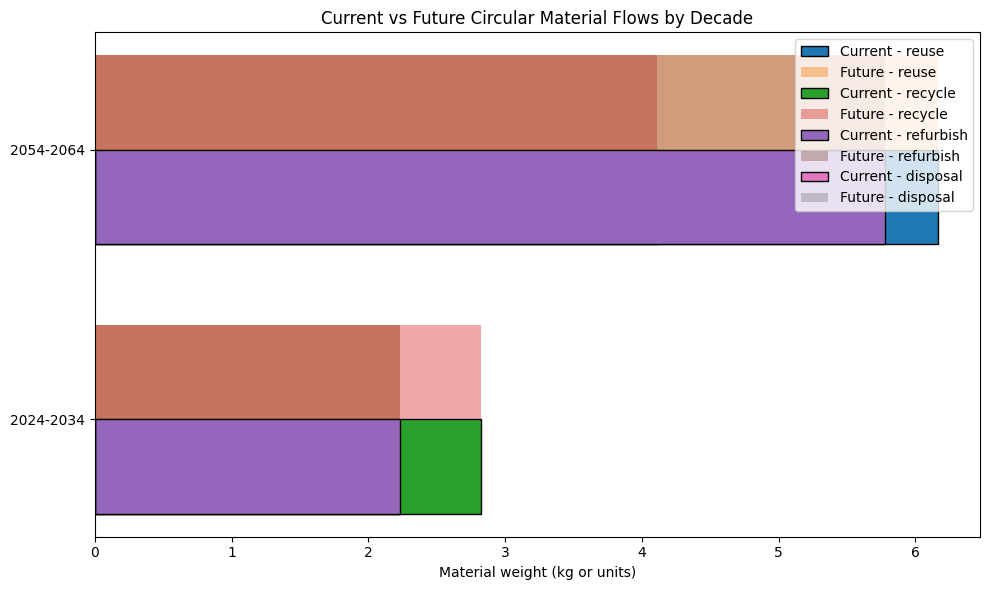

In [25]:
df_current = df
df_future = df_scenario

# Calculate end of life year and decade
def assign_decade(row):
    end_year = int(row['year_of_construction']) + 50
    if end_year < 2034:
        return '2024-2034'
    elif end_year < 2044:
        return '2034-2044'
    elif end_year < 2054:
        return '2044-2054'
    else:
        return '2054-2064'

df_current['decade'] = df_current.apply(assign_decade, axis=1)
df_future['decade'] = df_future.apply(assign_decade, axis=1)

# Function to compute total flow per category
def compute_flow(df):
    flows = df.copy()
    flow_records = []
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        grouped = flows.groupby('decade').apply(lambda x: (x['material_weight'] * x[category]).sum()).reset_index()
        grouped.columns = ['decade', category]
        flow_records.append(grouped.set_index('decade'))
    return pd.concat(flow_records, axis=1)

flow_current = compute_flow(df_current)
flow_future = compute_flow(df_future)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
decades = flow_current.index.tolist()
x = range(len(decades))

for i, cat in enumerate(['reuse', 'recycle', 'refurbish', 'disposal']):
    ax.barh(
        [xi - width/2 for xi in x],
        flow_current[cat],
        height=width,
        label=f'Current - {cat}',

        edgecolor='black'
    )
    ax.barh(
        [xi + width/2 for xi in x],
        flow_future[cat],
        height=width,
        label=f'Future - {cat}',
        alpha=0.4
    )

ax.set_yticks(x)
ax.set_yticklabels(decades)
ax.set_xlabel("Material weight (kg or units)")
ax.set_title("Current vs Future Circular Material Flows by Decade")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
